# Exercise 08 — Karate Club Split



In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

G = nx.karate_club_graph()

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Density:", round(nx.density(G), 4))
print("Connected:", nx.is_connected(G))

Nodes: 34
Edges: 78
Density: 0.139
Connected: True


## 2. Compute the degree distribution

We compute node degrees and summarize the distribution.


In [ ]:
degrees = dict(G.degree())
degree_values = list(degrees.values())

degree_df = pd.DataFrame({
    "node": list(degrees.keys()),
    "club": [G.nodes[n]["club"] for n in degrees.keys()],
    "degree": degree_values
}).sort_values("degree", ascending=False)

degree_df.head(10)

,node,club,degree
33,33,Officer,17
0,0,Mr. Hi,16
32,32,Officer,12
2,2,Mr. Hi,10
1,1,Mr. Hi,9
3,3,Mr. Hi,6
31,31,Officer,6
23,23,Officer,5
8,8,Mr. Hi,5
13,13,Mr. Hi,5


In [ ]:
summary_df = pd.DataFrame({
    "Statistic": [
        "Minimum degree",
        "Maximum degree",
        "Average degree",
        "Median degree",
        "Standard deviation"
    ],
    "Value": [
        np.min(degree_values),
        np.max(degree_values),
        np.mean(degree_values),
        np.median(degree_values),
        np.std(degree_values)
    ]
})

summary_df

,Statistic,Value
0,Minimum degree,1.000000
1,Maximum degree,17.000000
2,Average degree,4.588235
3,Median degree,3.000000
4,Standard deviation,3.820361


## 3. Degree distribution visualization

First we visualize the degree distribution directly.


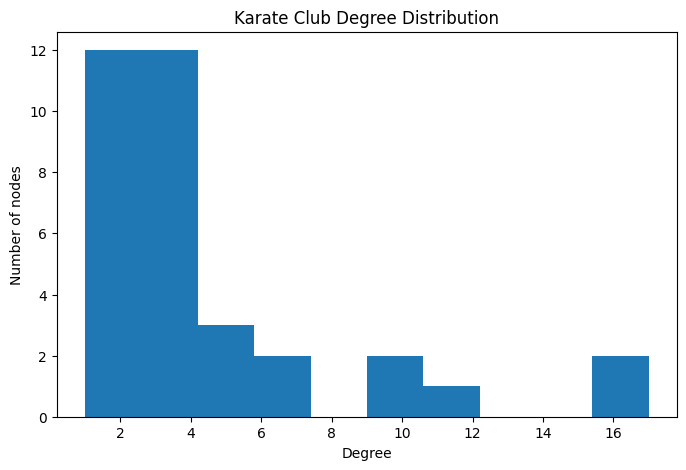

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(degree_values, bins=10)

plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.title("Karate Club Degree Distribution")
plt.show()

## 4. Log-log degree distribution

Heavy tails are easier to see on a log-log scale.

The Karate Club network is small, so this is only a rough visual check rather than a formal scale-free test.


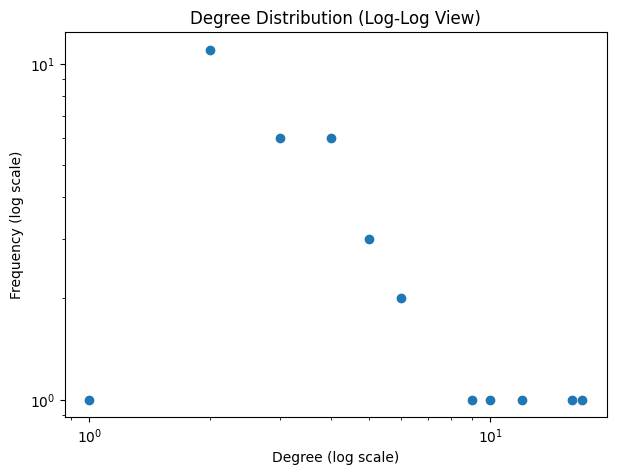

,count
1,1
2,11
3,6
4,6
5,3
6,2
9,1
10,1
12,1
16,1


In [ ]:
degree_counts = pd.Series(degree_values).value_counts().sort_index()

plt.figure(figsize=(7,5))

plt.scatter(degree_counts.index, degree_counts.values)

plt.xscale("log")
plt.yscale("log")

plt.xlabel("Degree (log scale)")
plt.ylabel("Frequency (log scale)")
plt.title("Degree Distribution (Log-Log View)")

plt.show()

degree_counts

## 5. Identify the top hubs

A hub is a node with substantially more connections than average.


In [ ]:
top_hubs = degree_df.head(10)

top_hubs

,node,club,degree
33,33,Officer,17
0,0,Mr. Hi,16
32,32,Officer,12
2,2,Mr. Hi,10
1,1,Mr. Hi,9
3,3,Mr. Hi,6
31,31,Officer,6
23,23,Officer,5
8,8,Mr. Hi,5
13,13,Mr. Hi,5


## 6. Compare hubs with earlier centrality results

We compare degree, betweenness centrality, and eigenvector centrality.


In [ ]:
betweenness = nx.betweenness_centrality(G)
eigenvector = nx.eigenvector_centrality(G, max_iter=1000)

centrality_df = pd.DataFrame({
    "node": list(G.nodes()),
    "club": [G.nodes[n]["club"] for n in G.nodes()],
    "degree": [degrees[n] for n in G.nodes()],
    "betweenness": [betweenness[n] for n in G.nodes()],
    "eigenvector": [eigenvector[n] for n in G.nodes()]
}).sort_values("degree", ascending=False)

centrality_df.head(10)

,node,club,degree,betweenness,eigenvector
33,33,Officer,17,0.304075,0.373371
0,0,Mr. Hi,16,0.437635,0.355483
32,32,Officer,12,0.145247,0.308651
2,2,Mr. Hi,10,0.143657,0.317189
1,1,Mr. Hi,9,0.053937,0.265954
3,3,Mr. Hi,6,0.011909,0.211174
31,31,Officer,6,0.138276,0.191036
23,23,Officer,5,0.017614,0.150123
8,8,Mr. Hi,5,0.055927,0.227405
13,13,Mr. Hi,5,0.045863,0.226470


The highest-degree hubs should largely overlap with the influential nodes identified in earlier exercises.


## 7. Measure degree inequality

A simple way to measure hub dominance is to compare the largest degree with the average degree.


In [ ]:
max_degree = np.max(degree_values)
avg_degree = np.mean(degree_values)

hub_ratio = max_degree / avg_degree

print("Maximum degree:", max_degree)
print("Average degree:", round(avg_degree, 2))
print("Hub dominance ratio:", round(hub_ratio, 2))

Maximum degree: 17
Average degree: 4.59
Hub dominance ratio: 3.71


## 8. Compare with a Barabási–Albert baseline

The BA model is generated using preferential attachment and often produces hub-dominated networks.

The baseline uses approximately the same number of nodes as the Karate Club graph.


In [ ]:
n = G.number_of_nodes()

# Similar average degree:
m = 2

BA = nx.barabasi_albert_graph(n=n, m=m, seed=42)

print("BA graph")
print("Nodes:", BA.number_of_nodes())
print("Edges:", BA.number_of_edges())
print("Average degree:", np.mean([d for _, d in BA.degree()]))

BA graph
Nodes: 34
Edges: 64
Average degree: 3.764705882352941


In [ ]:
ba_degrees = [d for _, d in BA.degree()]

comparison_df = pd.DataFrame({
    "Metric": [
        "Maximum degree",
        "Average degree",
        "Degree standard deviation"
    ],
    "Karate Club": [
        np.max(degree_values),
        np.mean(degree_values),
        np.std(degree_values)
    ],
    "BA baseline": [
        np.max(ba_degrees),
        np.mean(ba_degrees),
        np.std(ba_degrees)
    ]
})

comparison_df

,Metric,Karate Club,BA baseline
0,Maximum degree,17.000000,19.000000
1,Average degree,4.588235,3.764706
2,Degree standard deviation,3.820361,3.589681


## 9. Degree distribution comparison

Compare the Karate Club network with the BA baseline.


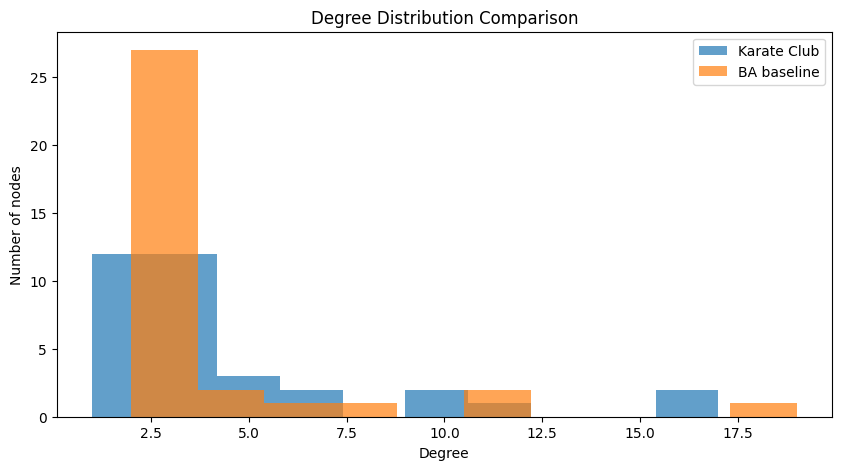

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(degree_values, bins=10, alpha=0.7, label="Karate Club")
plt.hist(ba_degrees, bins=10, alpha=0.7, label="BA baseline")

plt.xlabel("Degree")
plt.ylabel("Number of nodes")
plt.title("Degree Distribution Comparison")
plt.legend()

plt.show()

## 10. Hub dominance assessment

We classify the network using the observed degree inequality.


In [ ]:
if hub_ratio > 4:
    assessment = "Strong hub dominance"
elif hub_ratio > 2:
    assessment = "Mild to moderate hub dominance"
else:
    assessment = "No clear hub dominance"

print("Assessment:", assessment)

Assessment: Mild to moderate hub dominance
